# Librairies 📚

In [85]:
# =========================
# Standard library
# =========================
import os
import sys
from pathlib import Path
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)

# =========================
# Local imports (src/)
# =========================
# =========================
# Local imports (src/)
# =========================
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers as of
import src.distrib_pred_type as dpt
import src.analyse_bivariee as ab

/home/maxime/projects/technova-attrition


# Import de la table 🪑

In [86]:
df_back_up = pd.read_csv("/home/maxime/projects/technova-attrition/data/interim/data_eda.csv")
df_back_up.head(2)

,Unnamed: 0,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,...,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,...,1,0,0,1,1,2,Infra & Cloud,Occasionnel,0,5
1,1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,...,0,1,3,2,8,1,Infra & Cloud,Frequent,1,7


In [87]:
df = df_back_up.copy()
df.shape
df.drop("Unnamed: 0",axis=1,inplace=True)

# Etape 1 - Premier nettoyage des données 🧹

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   annee_experience_totale                    1470 non-null   int64  
 9   annees_dans_l_entreprise                   1470 non-null   int64  
 10  annees_dans_le_poste_act

In [89]:
df.drop("id_employee",axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
age,1470.0,36.923810,9.135373,18.00,30.00,36.00,43.00,60.00
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.00,2911.00,4919.00,8379.00,19999.00
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.00,1.00,2.00,4.00,9.00
annee_experience_totale,1470.0,11.279592,7.780782,0.00,6.00,10.00,15.00,40.00
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.00,3.00,5.00,9.00,40.00
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.00,2.00,3.00,7.00,18.00
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.00,2.00,3.00,4.00,4.00
note_evaluation_precedente,1470.0,2.729932,0.711561,1.00,2.00,3.00,3.00,4.00
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.00,1.00,2.00,3.00,5.00
satisfaction_employee_nature_travail,1470.0,2.728571,1.102846,1.00,2.00,3.00,4.00,4.00


### Valeurs nulles 👌(❎ pas de valeur nulle)

In [90]:
df.isna().mean().sort_values(ascending=False)

id_employee                                  0.0
age                                          0.0
annees_depuis_la_derniere_promotion          0.0
frequence_deplacement                        0.0
domaine_etude                                0.0
niveau_education                             0.0
distance_domicile_travail                    0.0
code_sondage                                 0.0
nb_formations_suivies                        0.0
nombre_participation_pee                     0.0
a_quitte_l_entreprise                        0.0
satisfaction_global                          0.0
augementation_salaire_precedente             0.0
heure_supplementaires                        0.0
note_evaluation_actuelle                     0.0
eval_number                                  0.0
satisfaction_employee_equilibre_pro_perso    0.0
satisfaction_employee_equipe                 0.0
satisfaction_employee_nature_travail         0.0
niveau_hierarchique_poste                    0.0
note_evaluation_prec

### Suppression des doublons 👥 (❎ Pas de doublons)

In [91]:
df.duplicated().sum()

0

# Analyses bivariées 🪢

In [92]:
data = df.select_dtypes(include="number")
data = data.drop(columns=["id_employee","eval_number","code_sondage"])

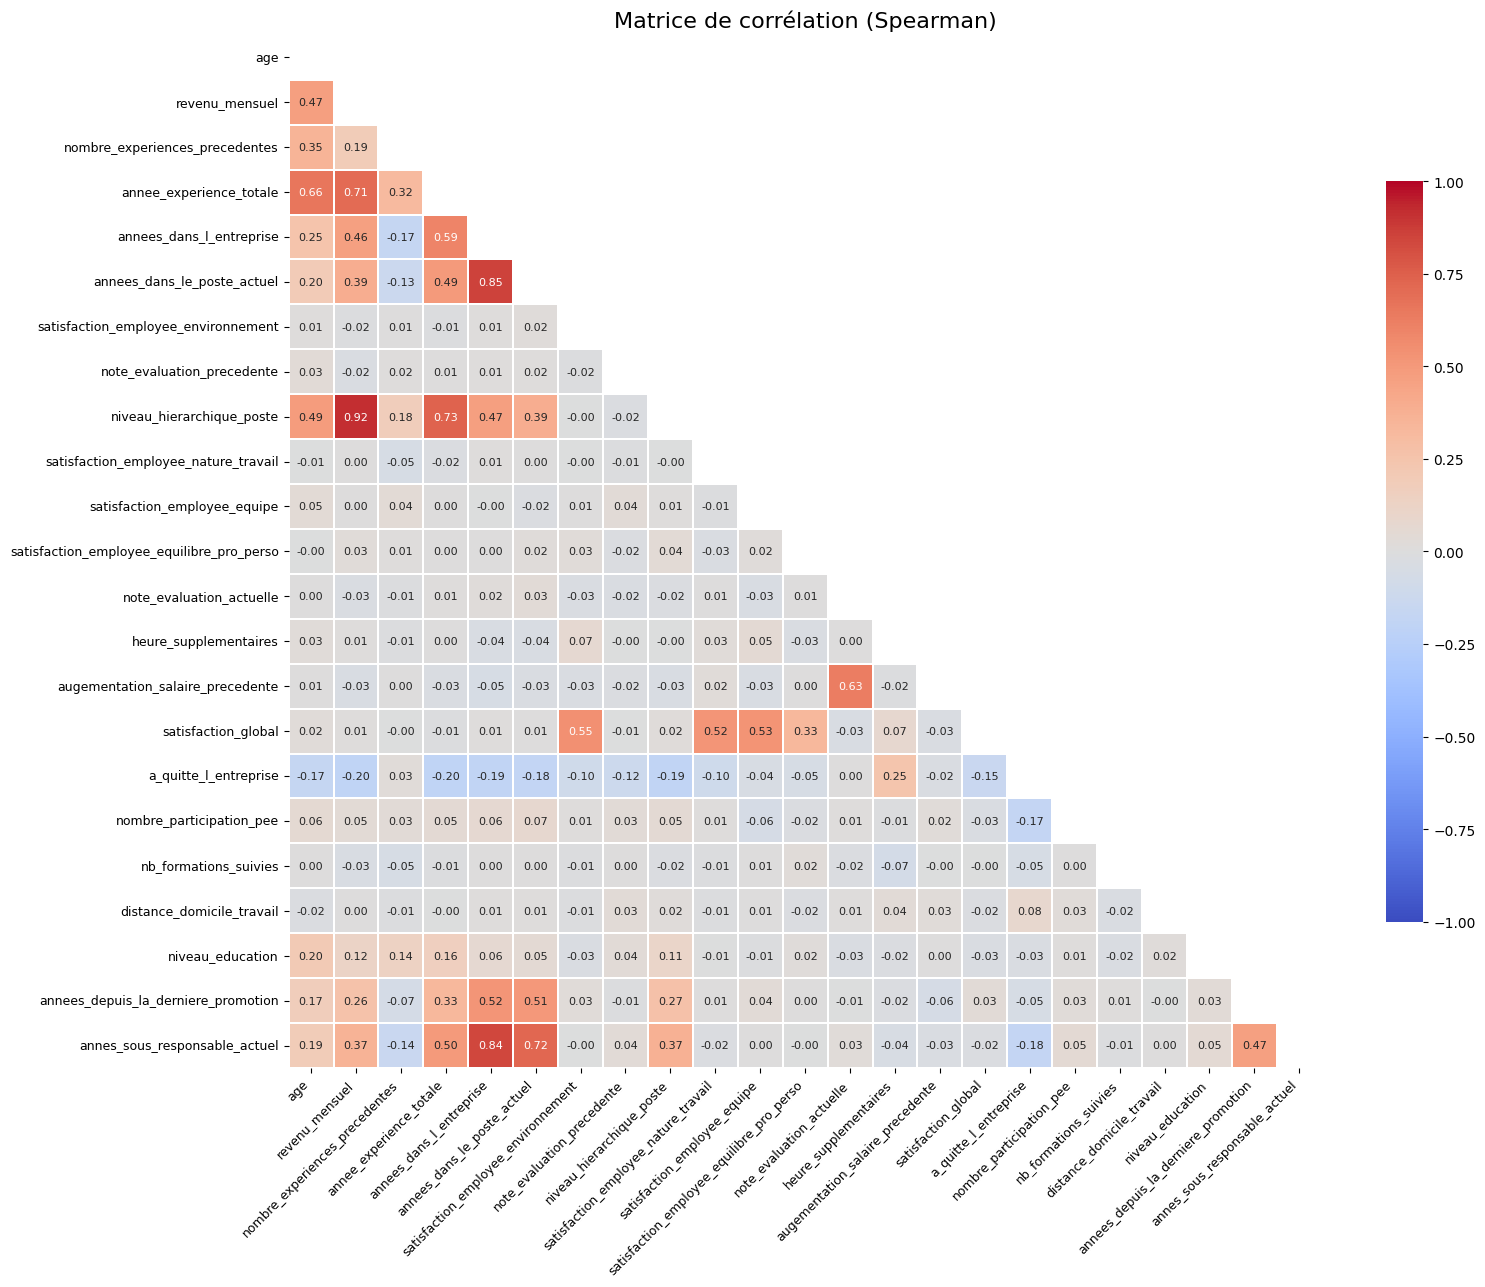

In [93]:
corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 16))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [94]:
corr = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,revenu_mensuel,niveau_hierarchique_poste,0.920429
1,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.854000
2,annees_dans_l_entreprise,annes_sous_responsable_actuel,0.842803
3,annee_experience_totale,niveau_hierarchique_poste,0.734678
4,annees_dans_le_poste_actuel,annes_sous_responsable_actuel,0.724754
5,revenu_mensuel,annee_experience_totale,0.710024


In [95]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = df[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

,feature,VIF
0,revenu_mensuel,23.931339
1,annee_experience_totale,9.726838
2,annees_dans_le_poste_actuel,6.085786
3,annees_dans_l_entreprise,8.980049
4,annes_sous_responsable_actuel,6.316925
5,niveau_hierarchique_poste,29.033025


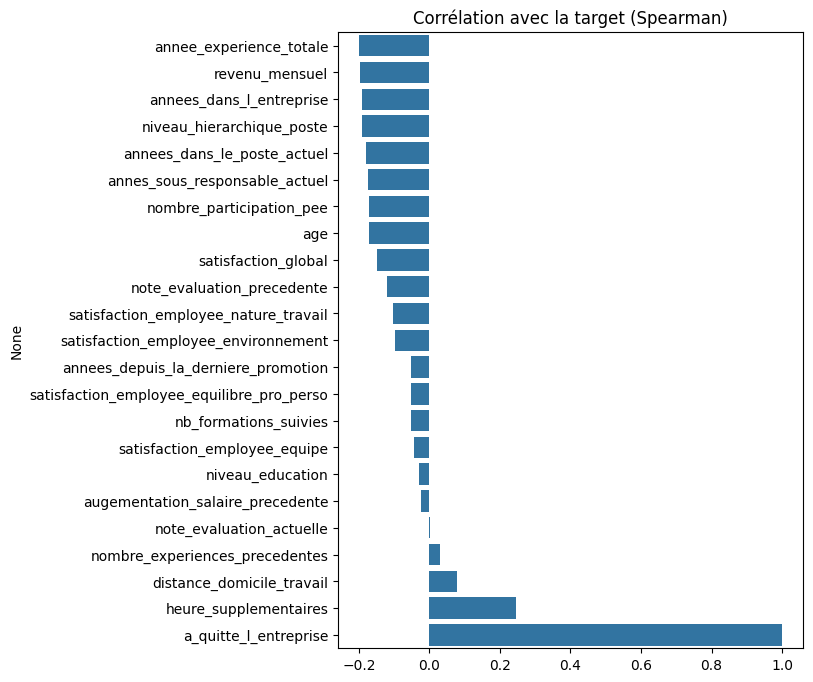

In [96]:
corr = data.corr(method="spearman")["a_quitte_l_entreprise"].sort_values()

plt.figure(figsize=(6,8))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Corrélation avec la target (Spearman)")
plt.show()

## Colonnes numériques

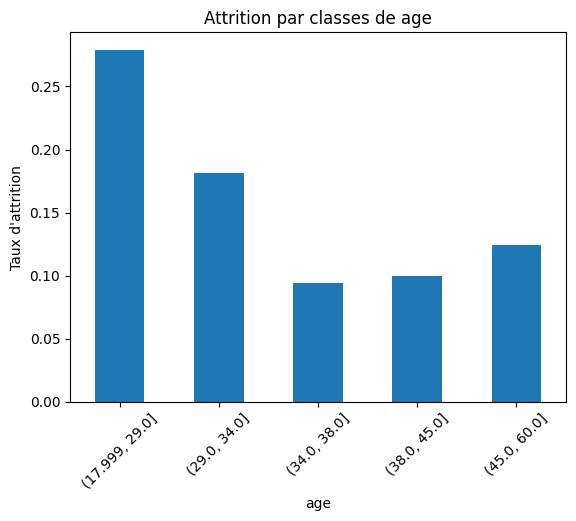

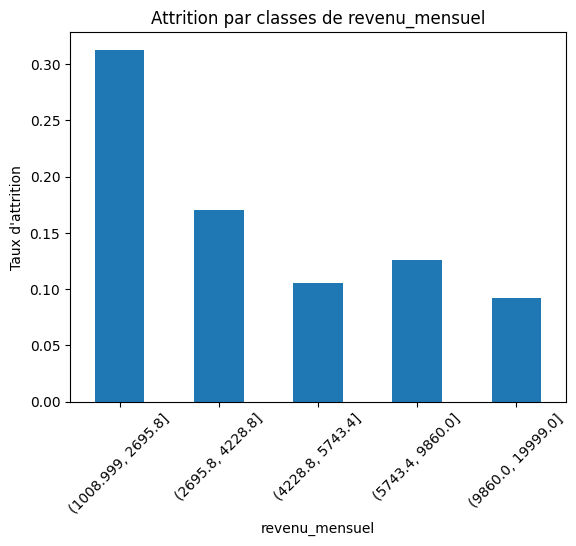

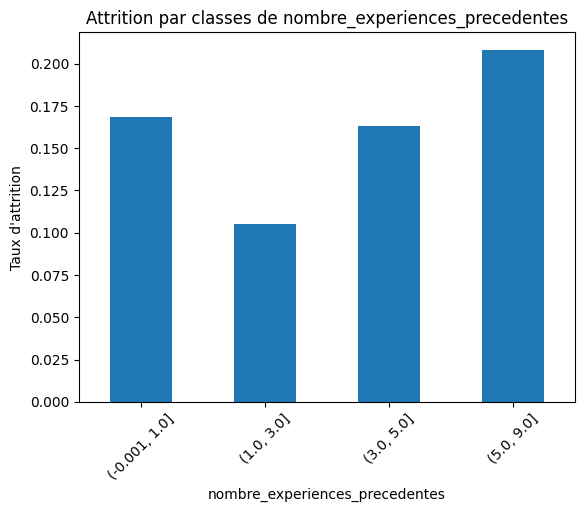

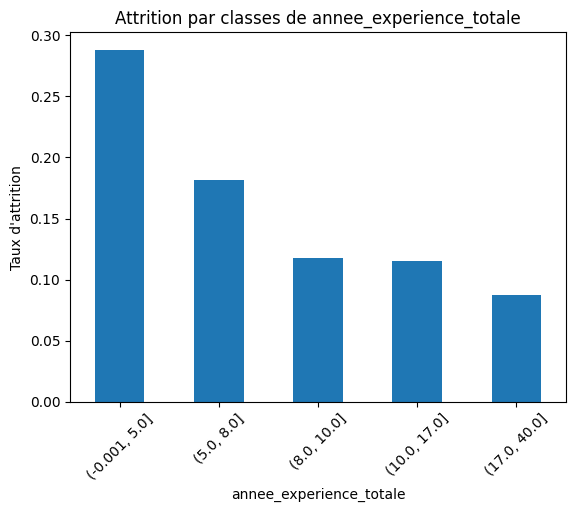

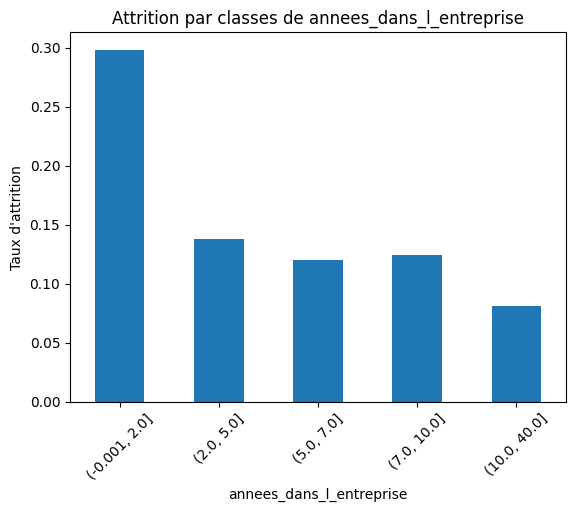

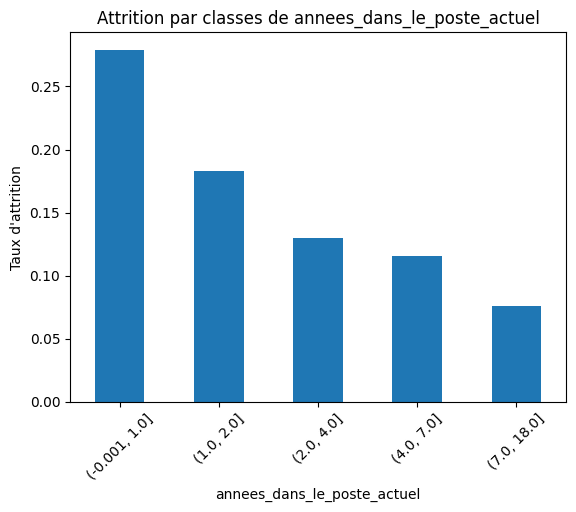

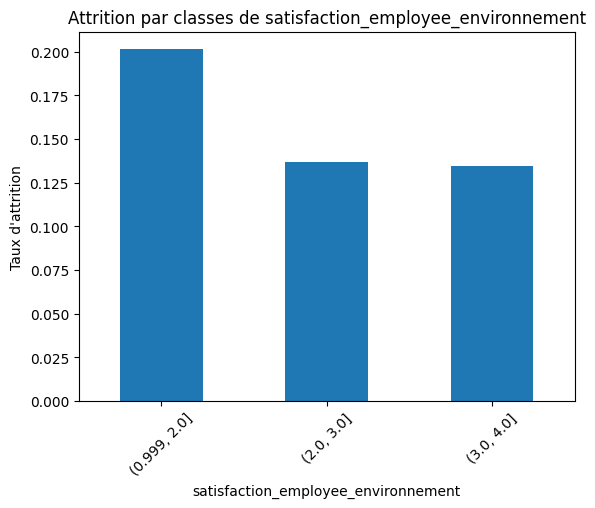

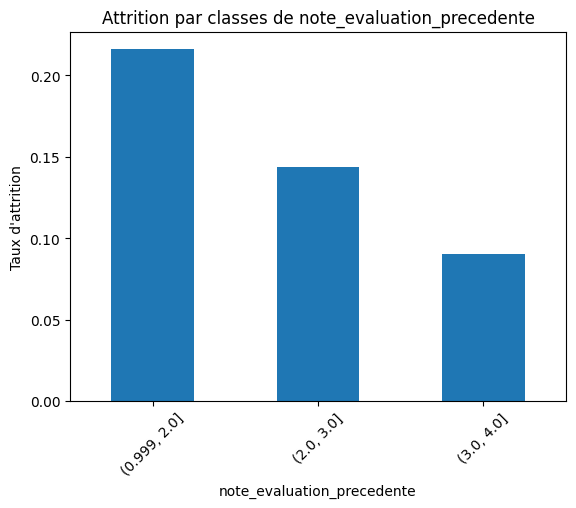

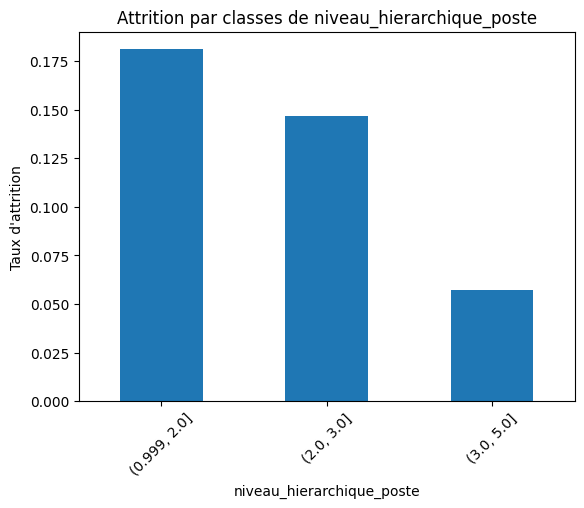

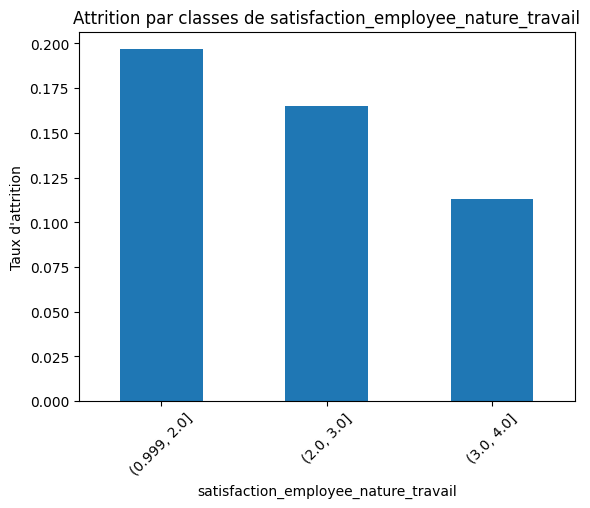

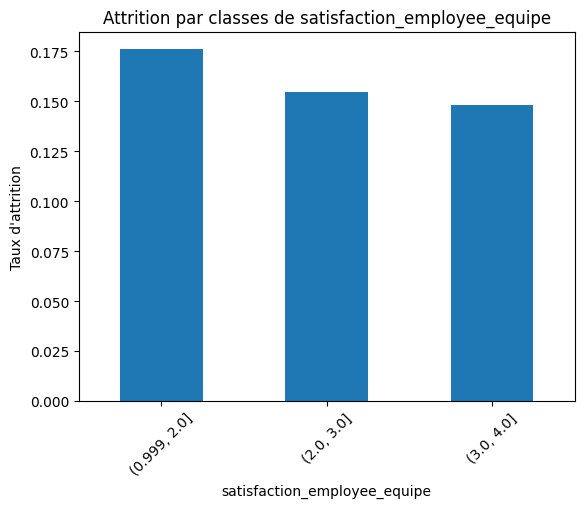

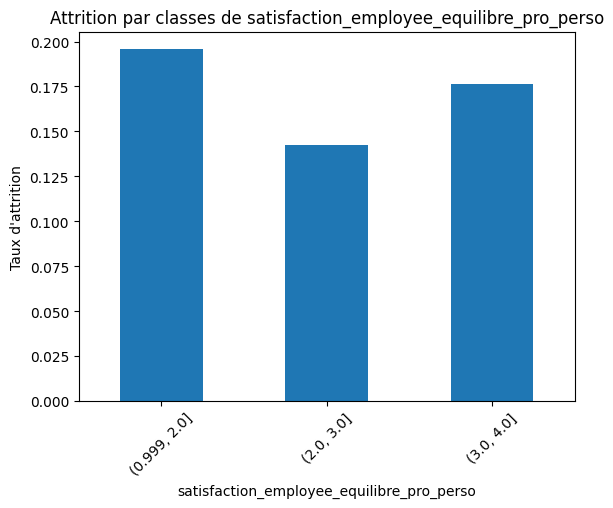

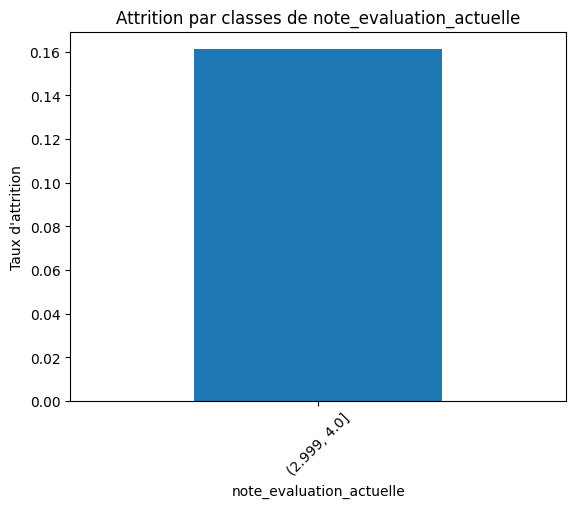

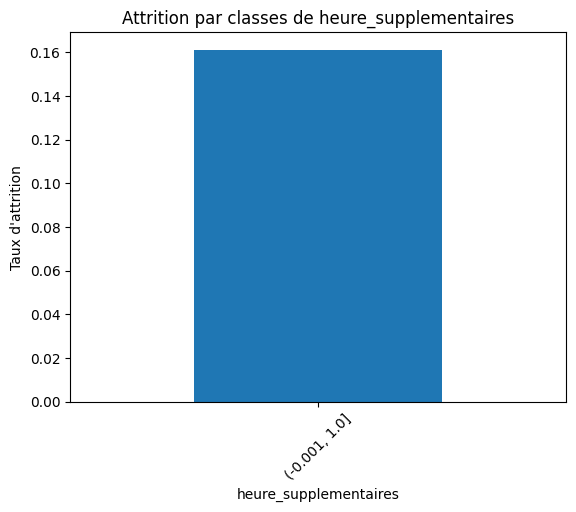

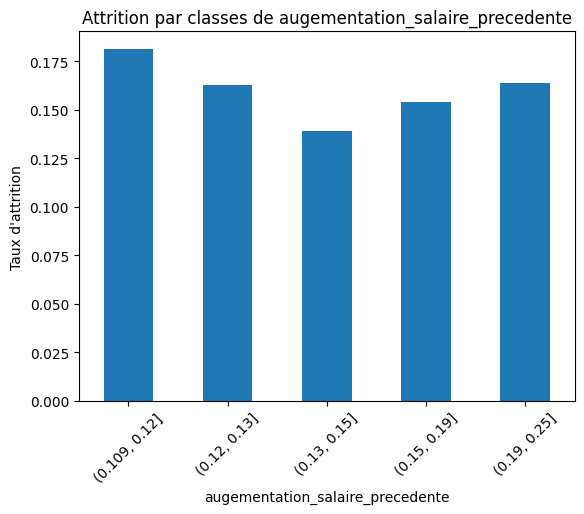

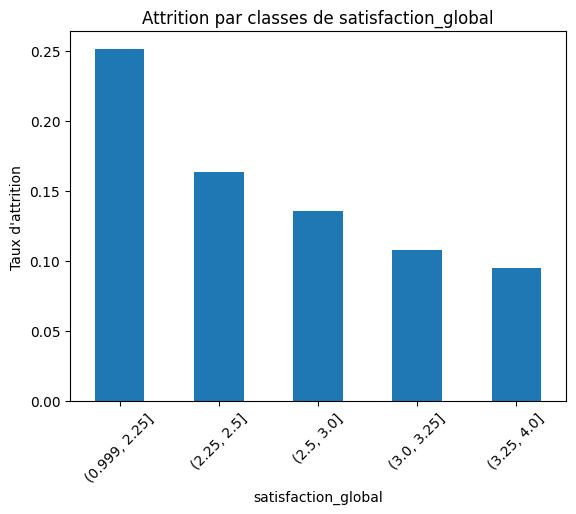

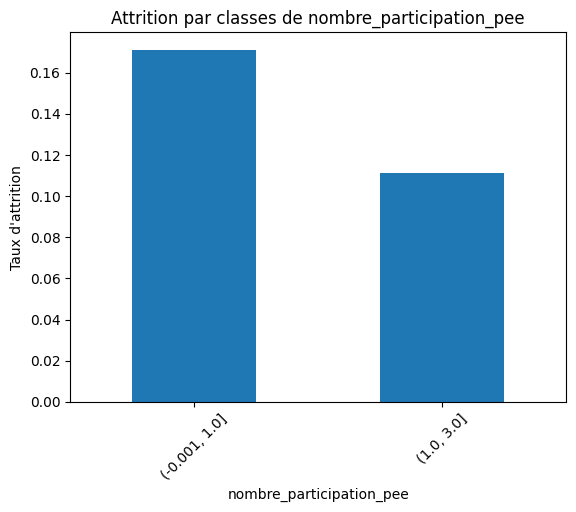

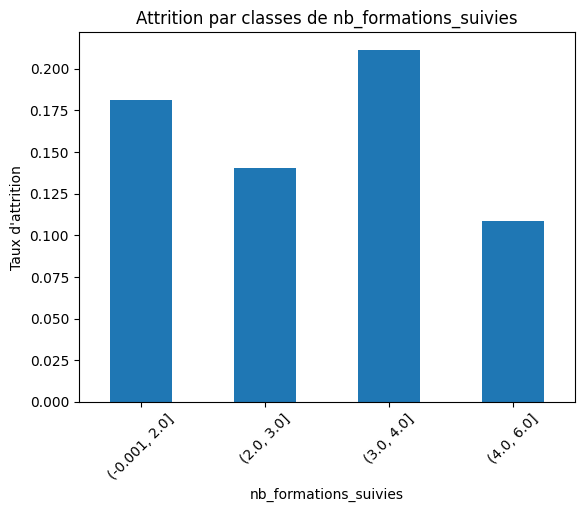

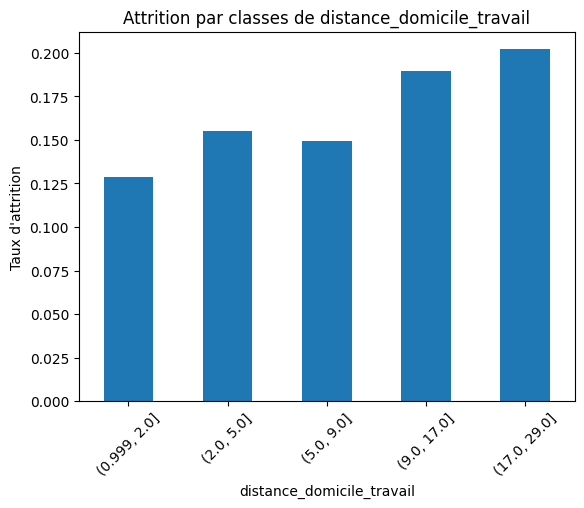

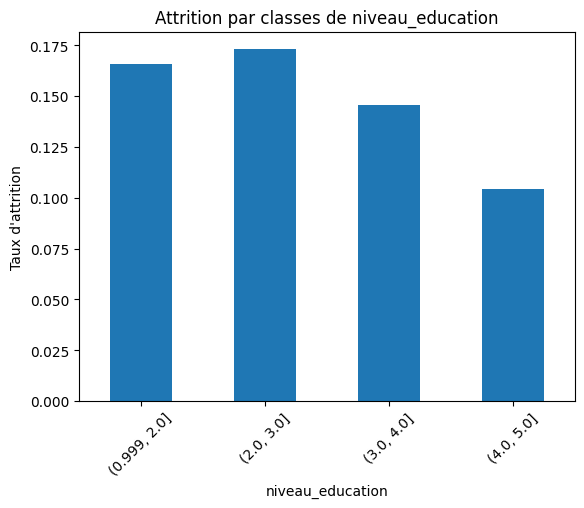

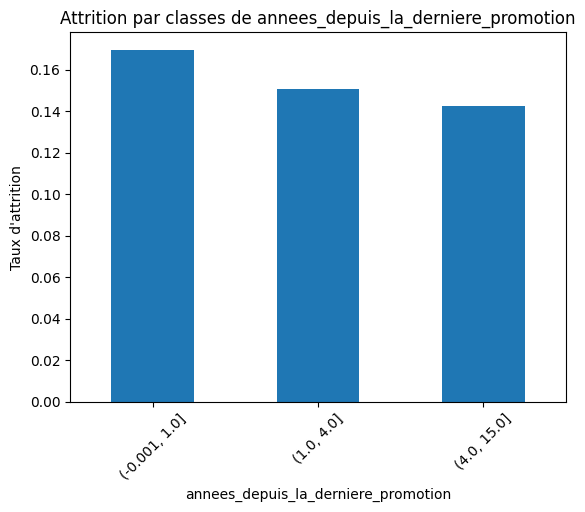

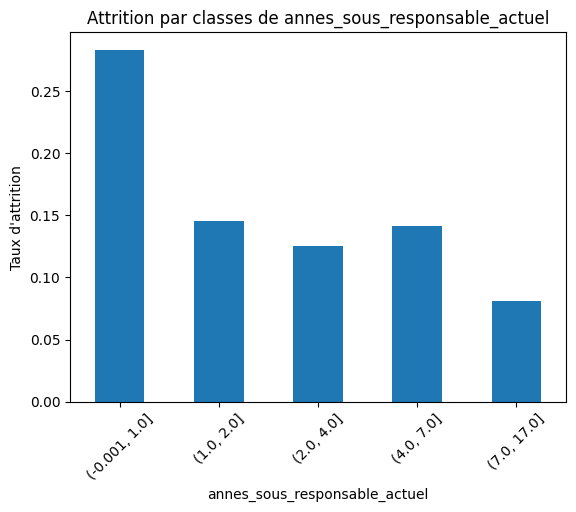

In [102]:
def plot_attrition_by_num(df, col, q=5):
    bins = pd.qcut(df[col], q=q, duplicates="drop")
    tmp = df.groupby(bins, observed=False)["a_quitte_l_entreprise"].mean()

    tmp.plot(kind="bar")
    plt.title(f"Attrition par classes de {col}")
    plt.ylabel("Taux d'attrition")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

data = df.drop(columns=["id_employee","eval_number","code_sondage"])

for col in data.select_dtypes(include="number").columns:
    if col != "a_quitte_l_entreprise" :
        plot_attrition_by_num(data, col)

## Colonnes catégorielles

In [103]:
df.select_dtypes(exclude="number").columns

Index(['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude',
       'frequence_deplacement', 'revenu_bin'],
      dtype='object')

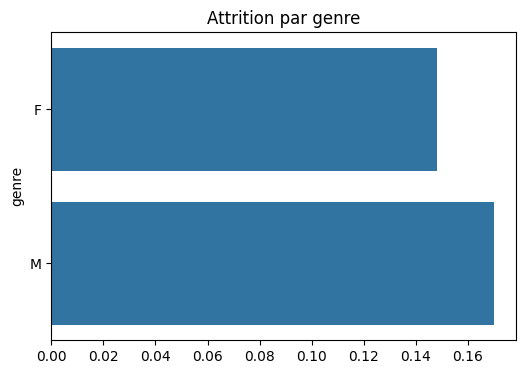

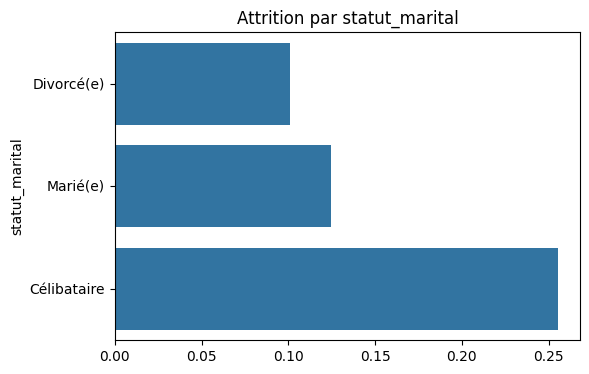

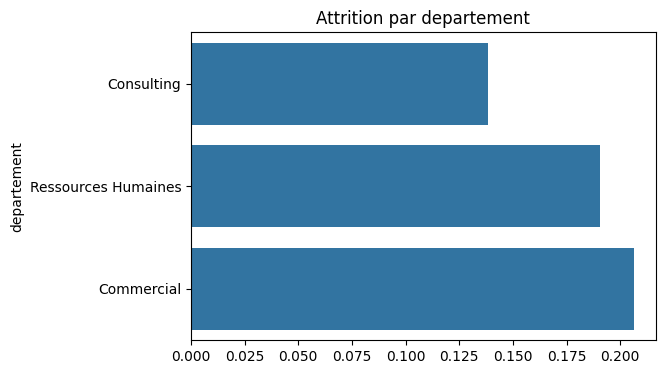

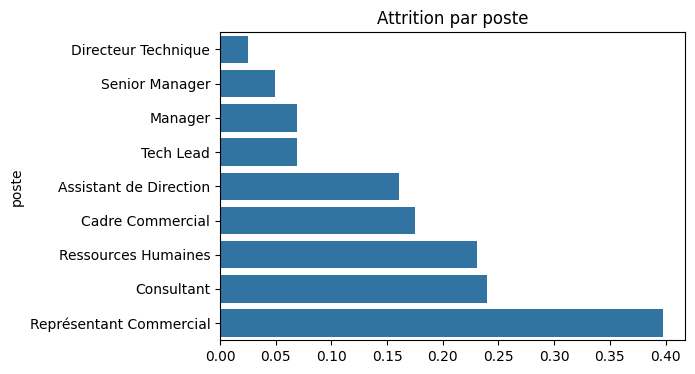

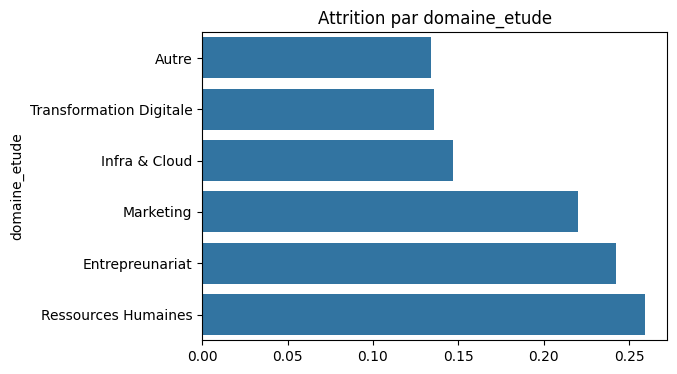

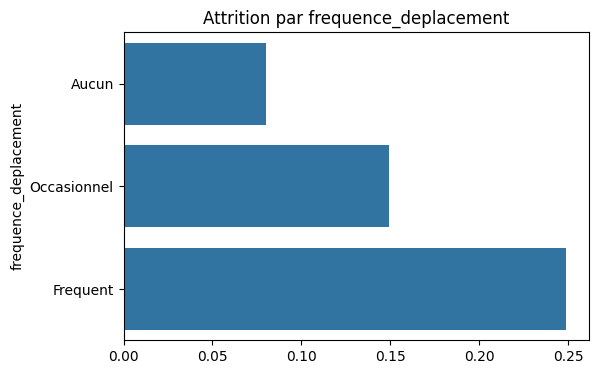

/tmp/ipykernel_120624/2633028822.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.groupby(col)["a_quitte_l_entreprise"].mean().sort_values()


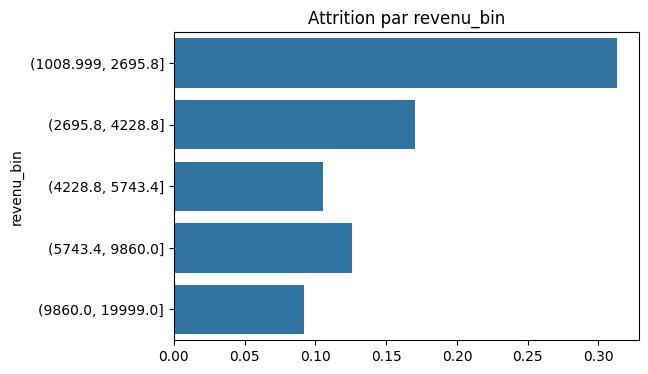

In [ ]:
def plot_attrition_by_cat(df, col):
    tmp = df.groupby(col)["a_quitte_l_entreprise"].mean().sort_values()

    plt.figure(figsize=(6,4))
    sns.barplot(x=tmp.values, y=tmp.index)
    plt.title(f"Attrition par {col}")
    plt.show()

for col in ['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude', 'frequence_deplacement']:
    plot_attrition_by_cat(df, col)

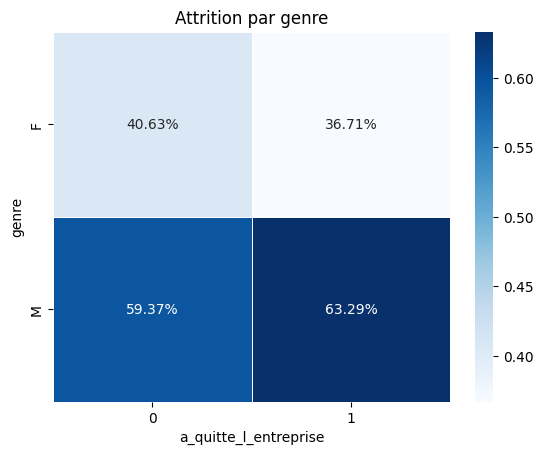

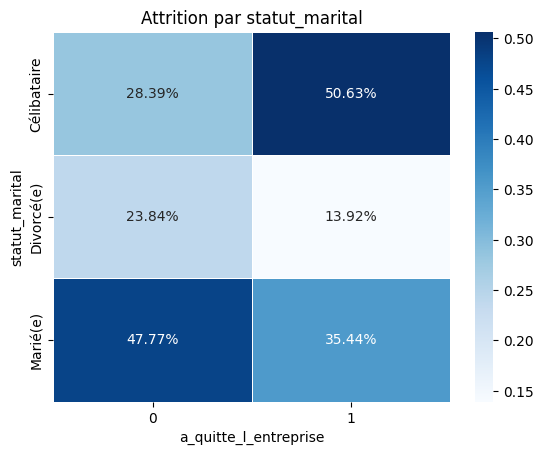

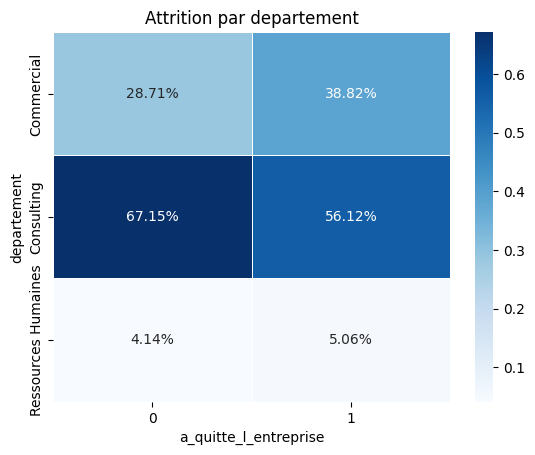

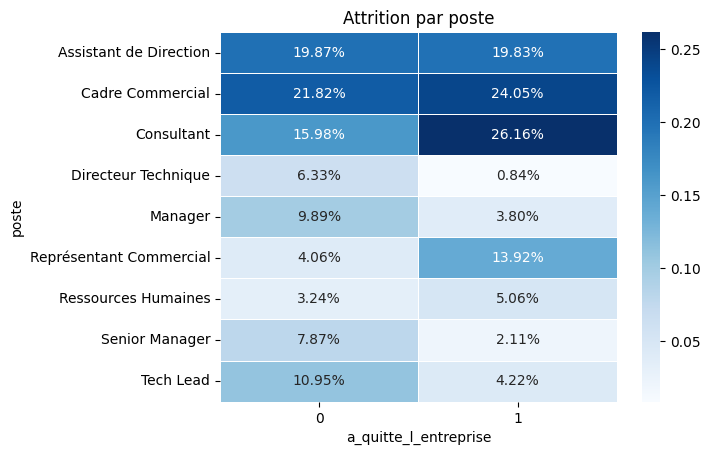

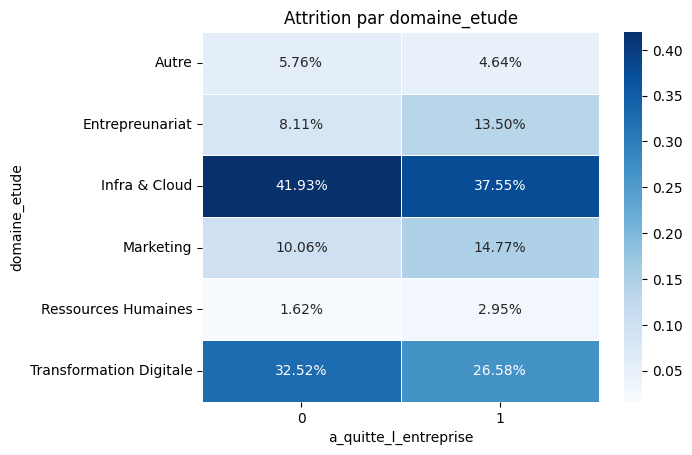

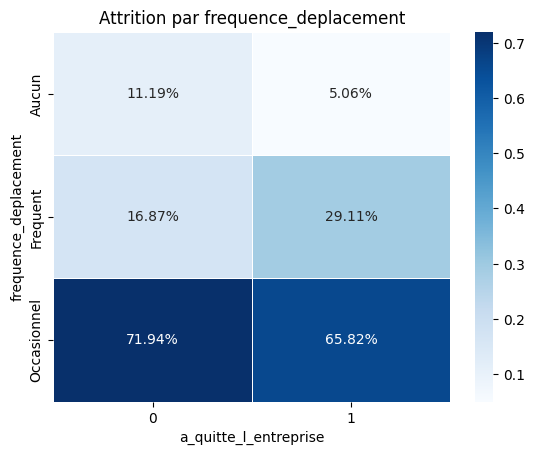

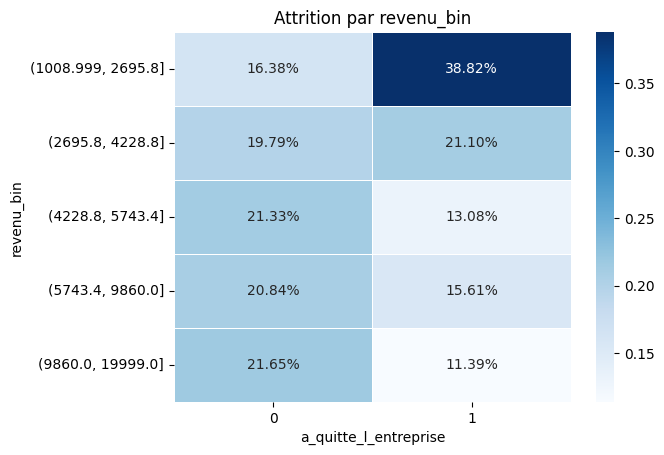

In [79]:
def plot_attrition_heatmap(df, col,norme='all'):
    ct = pd.crosstab( df[col], df["a_quitte_l_entreprise"], normalize=norme)

    sns.heatmap(
        ct,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        linewidths=0.5
    )
    plt.title(f"Attrition par {col}")
    plt.show()

for col in ['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude', 'frequence_deplacement', 'revenu_bin']:
    plot_attrition_heatmap(df, col, norme="columns")